In [1]:
from io import StringIO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # Import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 12 
NUM_16RND = 6

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")

# --- THE FIX: Overwrite the readfile function to handle 4 columns and empty lines ---
def readfile(filename):
    # 1. Add 'pkt_num' to absorb the extra column, and skip_blank_lines to ignore the gaps
    df = pd.read_csv(
        filename,
        skiprows=0,
        header=None,
        delimiter="|",
        on_bad_lines='skip',
        skip_blank_lines=True, 
        names=["time_rx", "pkt_num", "frame", "rssi"], 
        dtype=str
    )
    df.dropna(inplace=True)
    
    # 2. Cleanup whitespace
    df.time_rx = df.time_rx.str.strip()
    df.frame = df.frame.str.strip()
    df = df[df.frame.str.contains("packet overflow") == False]
    
    # 3. Cleanup RSSI (removes "CRC error" and keeps the number)
    df.rssi = df.rssi.str.strip().str.split(" ", expand=True).iloc[:,0]
    df.rssi = df.rssi.astype('int')
    
    # 4. Parse frame sequence and payload
    df = df[df.frame.str.len() >= 6]
    df['seq'] = df.frame.apply(lambda x: int(x[3:5], base=16))
    df['payload'] = df.frame.apply(lambda x: x[6:])
    
    # 5. Drop the pkt_num column since we don't need it
    df = df.drop(columns=['frame', 'pkt_num'])
    df.reset_index(inplace=True, drop=True)
    
    return df

## Log file

**For a fair comparison between groups, must follow the output format below**
<br>$\color{red}{\text{timestamp\_rx }| \text{ len [hex] } \text{ seq [hex] } \text{ payload [hex] }| \text{rssi} }$
<br>$\text{ len [hex]}$ = payload length + 1 (seq. field length [1B])
<br>$\text{ payload [hex]}$ should start with the pseudo sequence number [2B], indicates the starting byte's position in the file.
***
*Example log file output for one frame with reciever timestamp xxxx, frame length, seq number and random payload, received signal strength.*
<br>15:17:18.394 |0f 46 bd f8 f7 ea 41 ac 1b be 05 a0 7f d2 09 d4 |  -91 CRC error
<br>$\color{red}{\text{delimiter for four variables is "|" and delimiter for the payload each byte is the space " ".}}$

In [2]:
# 1. DEFINE YOUR CSV FILE NAMES HERE (Without the .csv extension)
files_100k = {
    0: "100k_1_converted",     # Replace with your actual 0cm filename
    75: "100k_2_converted",   # Replace with your actual 75cm filename
    150: "100k_3_converted", # Replace with your actual 150cm filename
    225: "100k_4_converted", # Replace with your actual 225cm filename
    300: "100k_5_converted"  # Replace with your actual 300cm filename
}

files_50k = {
    225: "50k_4_converted",  # Replace with your actual 50k 225cm filename
    300: "50k_5_converted"   # Replace with your actual 50k 300cm filename
}

# 2. BATCH ANALYSIS FUNCTION
def analyze_log(filename):
    df = readfile("./" + filename + ".csv")
    test = df[df.payload.apply(lambda x: len(x) == ((PAYLOADSIZE) * 3 - 1))]
    test.reset_index(inplace=True)
    
    if len(test) < 1:
        return 0, 0, 0 # data_rate, reliability, packets
        
    start_time = pd.to_datetime(df.time_rx.iloc[0], format='%H:%M:%S.%f')
    end_time = pd.to_datetime(df.time_rx.iloc[-1], format='%H:%M:%S.%f')
    file_delay_s = (end_time - start_time).total_seconds()
    
    ber = compute_ber(test, PACKET_LEN=PAYLOADSIZE)
    bit_reliability = (1 - ber) * 100
    
    if file_delay_s > 0:
        data_rate = (len(test) * PAYLOADSIZE * 8) / file_delay_s
    else:
        data_rate = 0
        
    return data_rate, bit_reliability, len(test)

# 3. RUN THE ANALYSIS
results_100k = {}
for dist, fname in files_100k.items():
    print(f"--- Processing 100k at {dist} cm ---")
    dr, rel, pkts = analyze_log(fname)
    results_100k[dist] = {'data_rate': dr, 'reliability': rel, 'packets': pkts}

results_50k = {}
for dist, fname in files_50k.items():
    print(f"\n--- Processing 50k at {dist} cm ---")
    dr, rel, pkts = analyze_log(fname)
    results_50k[dist] = {'data_rate': dr, 'reliability': rel, 'packets': pkts}

--- Processing 100k at 0 cm ---
The total number of packets transmitted by the tag is 185.
--- Processing 100k at 75 cm ---
The total number of packets transmitted by the tag is 177.
--- Processing 100k at 150 cm ---
The total number of packets transmitted by the tag is 70.
--- Processing 100k at 225 cm ---
The total number of packets transmitted by the tag is 161.
--- Processing 100k at 300 cm ---
The total number of packets transmitted by the tag is 49.

--- Processing 50k at 225 cm ---
The total number of packets transmitted by the tag is 229.

--- Processing 50k at 300 cm ---
The total number of packets transmitted by the tag is 229.


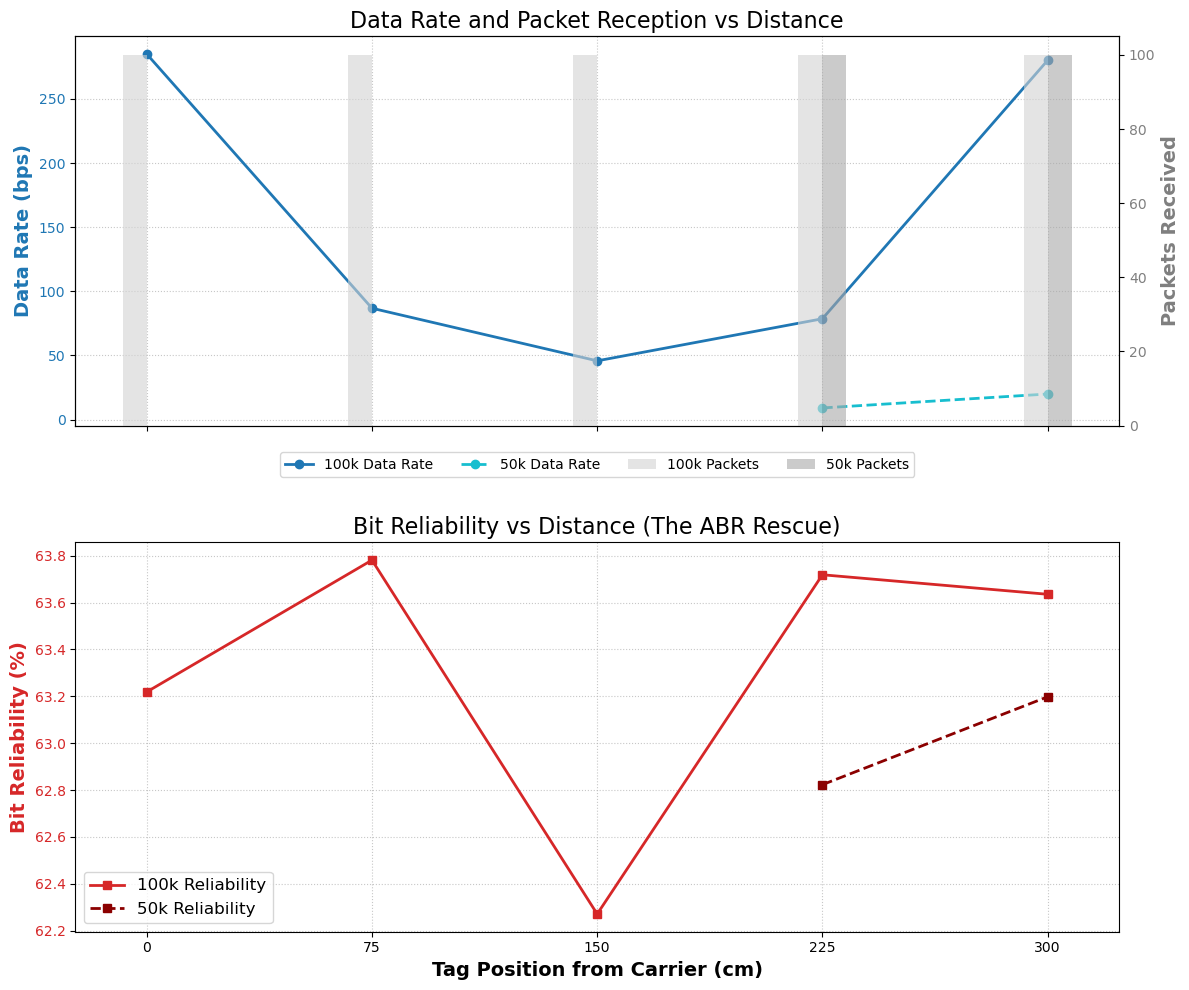

In [3]:
# Extract data for plotting
distances_100k = list(results_100k.keys())
dr_100k = [results_100k[d]['data_rate'] for d in distances_100k]
rel_100k = [results_100k[d]['reliability'] for d in distances_100k]
pkts_100k = [results_100k[d]['packets'] for d in distances_100k]

distances_50k = list(results_50k.keys())
dr_50k = [results_50k[d]['data_rate'] for d in distances_50k]
rel_50k = [results_50k[d]['reliability'] for d in distances_50k]
pkts_50k = [results_50k[d]['packets'] for d in distances_50k]

# Create Figure
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Subplot 1: Data Rate & Packets ---
color_dr = 'tab:blue'
ax1.set_ylabel('Data Rate (bps)', color=color_dr, fontsize=14, fontweight='bold')
ax1.plot(distances_100k, dr_100k, marker='o', color=color_dr, linewidth=2, label="100k Data Rate")
ax1.plot(distances_50k, dr_50k, marker='o', color='tab:cyan', linewidth=2, linestyle='--', label="50k Data Rate")
ax1.tick_params(axis='y', labelcolor=color_dr)

ax2 = ax1.twinx()
color_pkt = 'tab:gray'
ax2.set_ylabel('Packets Received', color=color_pkt, fontsize=14, fontweight='bold')
# Use offset bars so they don't overlap perfectly
ax2.bar([x - 4 for x in distances_100k], pkts_100k, width=8, color='lightgray', alpha=0.6, label="100k Packets")
ax2.bar([x + 4 for x in distances_50k], pkts_50k, width=8, color='darkgray', alpha=0.6, label="50k Packets")
ax2.tick_params(axis='y', labelcolor=color_pkt)

ax1.set_title("Data Rate and Packet Reception vs Distance", fontsize=16)
ax1.grid(True, linestyle=':', alpha=0.7)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4)

# --- Subplot 2: Bit Reliability ---
color_rel = 'tab:red'
ax3.set_xlabel('Tag Position from Carrier (cm)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Bit Reliability (%)', color=color_rel, fontsize=14, fontweight='bold')
ax3.plot(distances_100k, rel_100k, marker='s', linestyle='-', color=color_rel, linewidth=2, label="100k Reliability")
ax3.plot(distances_50k, rel_50k, marker='s', linestyle='--', color='darkred', linewidth=2, label="50k Reliability")
ax3.tick_params(axis='y', labelcolor=color_rel)

ax3.set_xticks(distances_100k)
ax3.set_title("Bit Reliability vs Distance (The ABR Rescue)", fontsize=16)
ax3.grid(True, linestyle=':', alpha=0.7)
ax3.legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3) # Give room for the middle legend
plt.savefig("abr_performance_summary.pdf", bbox_inches='tight') 
plt.show()

# Time

## Definition

**Evaluation metric**
<br>*File Transmission Time: the total latency that certain amount of Data $F$ is delivered to the destination.*
<br> $File\ Delay = Rx\_timestamp[N] - Rx\_timestamp[0]$
<br> where $N$ is the last packet
***
**Interesting to look at**:
<br>*Timestamp difference*: $\Delta T[i] = Rx\_timestamp[i] - Tx\_timestamp[i]$
1. *Worst-case packet delay*: the delay of the packet that takes the longest time to traverse.
2. *Packet delay variation*: the std of the packet delay.

In [12]:
# CHANGE: Convert strings back to datetime for subtraction
start_time = pd.to_datetime(df.time_rx.iloc[0], format='%H:%M:%S.%f')
end_time = pd.to_datetime(df.time_rx.iloc[-1], format='%H:%M:%S.%f')

file_delay = end_time - start_time

# Convert the timedelta to seconds
file_delay_s = file_delay.total_seconds() 

print(f"The time it takes to transfer the file is: {file_delay}, which is {file_delay_s} seconds.")

The time it takes to transfer the file is: 0 days 00:05:31.010000, which is 331.01 seconds.


# Reliability

## Definition

**Evaluation metric**
<br>*Quality of data transfer.*
<br>*Bit Reliability*: The ratio of data bits correctly delivered to the data sink.
<br>*Bit Error Rate*: The ratio of data bits incorrectly delivered to the data sink.
$$Bit\ Reliability = 1 - BER = 1 - \frac{Number\ of\ wrong\ bit}{Total\ Number\ of\ bit\ received}$$
<br>*Achieved Data Rate*: The bit error rate is calculated based on the received data only. Missing packets do not affect the bit error rate, but are reflected in the achievable data rate.

## Statistics

In [13]:
# compute the BER for all received packets
# Use the 'test' dataframe (the filtered one)
ber = compute_ber(test, PACKET_LEN=PAYLOADSIZE)
bit_reliability = (1 - ber) * 100

print(f"Bit error rate [%]: {(ber * 100):.8f}")

if len(test) < 1:
    print("Data rate [bit/s]: More than one packet required for analysis.")
else:
    # Calculation: (Number of packets * Bytes per packet * 8 bits) / seconds
    data_rate = (len(test) * PAYLOADSIZE * 8) / file_delay_s
    print(f"Data rate [bit/s]: {data_rate:.2f}")

The total number of packets transmitted by the tag is 109.
Bit error rate [%]: 37.34452736
Data rate [bit/s]: 38.86


Note: if individual packets have a high bit-error rate...


Text(0.5, 0, 'Packet Index')

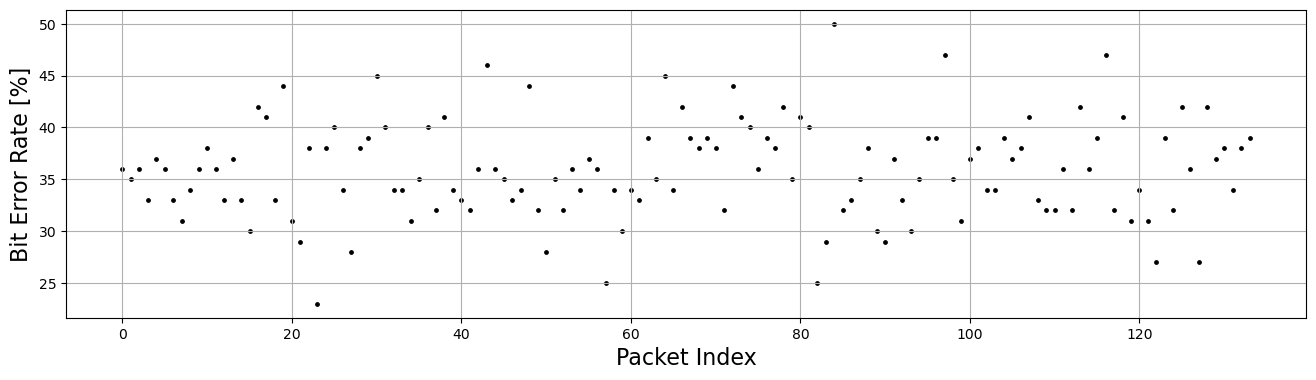

In [14]:
# Updated Plot Block for Test 3
print("Note: if individual packets have a high bit-error rate...")

# 1. Ensure we only plot rows that have a valid payload
valid_df = test[test['payload'].notna()]

# 2. Plot using the filtered 'valid_df' and ensure PACKET_LEN matches PAYLOADSIZE
# We use PAYLOADSIZE from your previous block
plt.scatter(
    range(len(valid_df)), 
    [compute_ber_packet(row, PACKET_LEN=PAYLOADSIZE)[0] for (_, row) in valid_df.iterrows()], 
    marker='o', s=6, color='black'
)

plt.grid()
plt.ylabel('Bit Error Rate [%]', fontsize=16)
plt.xlabel('Packet Index', fontsize=16)

# Distance

## Definition

**The communication distance of the system.**
<br>$D_{1}$: the distance between carrier<->backscatter_tag[m]
<br>$D_{2}$: the distance between backscatter_tag<->receiver[m]
<br> Distance metric = $D_{1}^2D_{2}^2$
<br>

In [15]:
# record the distance
dis_carrier_tag = 1
dis_tag_rx = 4

dis_metric = dis_carrier_tag**2*dis_tag_rx**2
print(f"Distance metric is: {dis_metric}")

Distance metric is: 16


# Radarplot

**Please pay attention to the unit**
<br> <font color='red'>Time</font>: use second as unit
<br> <font color='red'>Reliability</font>: use the percent as unit
<br> <font color='red'>Distance</font>: use meter as unit
<br>**Metics = [Time(s), Reliability(%), Distance(m)]**
<br> <font color='red'>Always keep the reference in your plot.</font>
<br> Tips: for ploting, time metric uses $\frac{1}{Time}*1000$ as the time metric, the higher the value the better the system performance

[331.01, 62.65547263681592, 16]


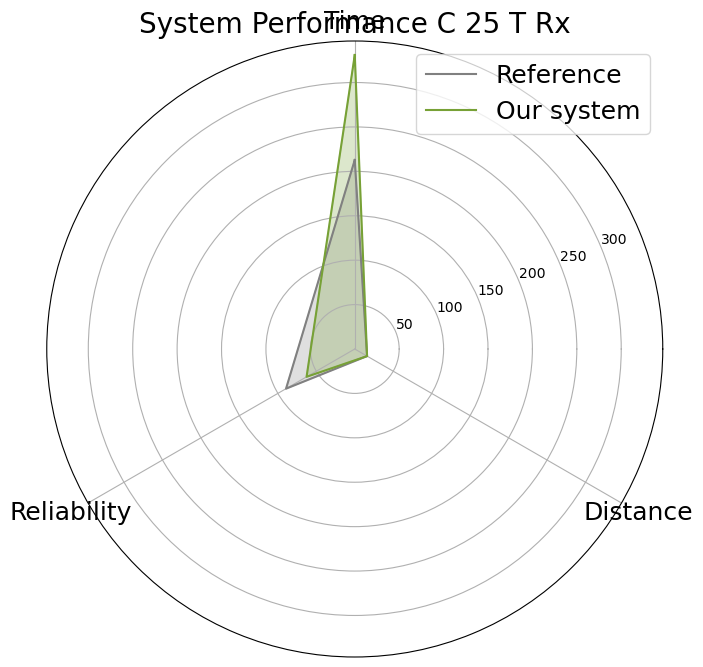

In [16]:
metrics = [file_delay_s, bit_reliability, dis_metric]

system_ref_baseline_c25 = [57.284, 96.41, 16] # C ->(25cm) Tag
system_ref_baseline_c50 = [np.float64(100.318), 92.21428571428572, 16] # C ->(50cm) Tag
system_ref_baseline_middle = [0, 0, 0] # C -> (150) Tag -> (150) Receiver
system_ref_baseline_rx50 = [np.float64(212.826), 89.36160714285715, 16] # Tag ->(50cm) Receiver
system_ref_baseline_rx25 = [np.float64(121.055), 91.36607142857143, 16] # # Tag ->(25cm) Receiver


print(metrics)
#                                                 25cm                            3m
title = "System Performance C 25 T Rx" # Carrier ------> Tag -> Receiver (Carrier --> Receiver)
radar_plot(metrics, system_ref=system_ref_baseline_rx50, title=title)

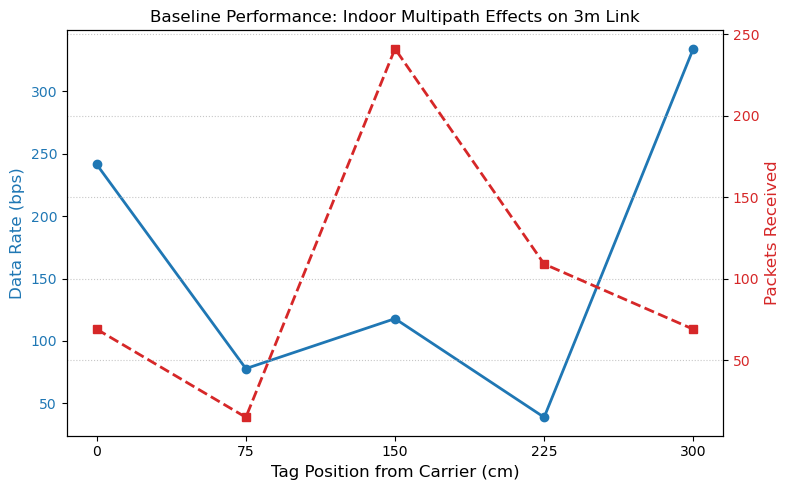

In [17]:
import matplotlib.pyplot as plt

# Your NEW collected data
distances = [0, 75, 150, 225, 300]
data_rates = [241.36, 77.86, 117.87, 38.86, 334.04]
packets = [69, 15, 241, 109, 69]

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Tag Position from Carrier (cm)', fontsize=12)
ax1.set_ylabel('Data Rate (bps)', color=color, fontsize=12)
ax1.plot(distances, data_rates, marker='o', color=color, linewidth=2, label="Data Rate")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(distances)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Packets Received', color=color, fontsize=12)
ax2.plot(distances, packets, marker='s', linestyle='--', color=color, linewidth=2, label="Packets")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Baseline Performance: Indoor Multipath Effects on 3m Link")
fig.tight_layout()  
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig("summary_performance.pdf") 
plt.show()